# Asian Option Example

Author: Fred J. Hickernell + ChatGPT

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\reals}{\mathbb{R}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/KeisterExample.ipynb?flush_cache=true)

In [1]:
# Colab-only setup
if "google.colab" in str(get_ipython()):
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop

### Import needed packages and initialize some parameters

In [2]:
import sys
import time
from pathlib import Path
import numpy as np
from scipy import stats
import qmcpy as qp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent  # Ensure repo root is on sys.path (for local 'classlib' and 'nbviz')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from classlib.options.asian import bm_transform, asian_arith_mean_call_payoff
import classlib.nbviz as nb
nb.init(use_tex=True)     # styling, Tol cycle, CSS
colors, TINY = nb.TOL_BRIGHT, nb.TINY

## Asian Arithmetic Mean Option
Brownian motions are used in financial modeling.  If 
- $S_0$ is the initial price of a stock/asset
- $r$ is the interest rate
- $\sigma$ is the volatility
Then
$$
S(t) = S_0 \exp\bigl((r -\sigma^2/2)t  + \sigma B(t) \bigr)
$$
is a _geometric Brownian motion_ model of the stock price.

The payoff of an Asian Arithmetic Mean call option is
$$ 
\max\left(\frac 1T \int_0^T S(t) \mathrm{d} t - K, 0 \right) \exp(-rT)
$$ 
where $T$ is the time to maturity and $K$ is the strike price.  We can approximate this integral by the trapezoidal rule.

Below is a function that computes an discounted option payoff for an Asian arithmetic mean call.

In [15]:
# Asian Option Parameters
T=0.25 #time to expiration
d=13 #number of time steps
S0=100 #initial stock price
r=0.03 #interest rate
sigma=0.4 #volatility
K=100 #strike price

In [20]:
A = bm_transform(T=0.25, d=13) #square root of the covariance matrix
n=2**17

Sobol = qp.Sobol(d).gen_samples(n)
IID = qp.IIDStdUniform(d).gen_samples(n)
pay = asian_arith_mean_call_payoff(IID, S0=S0, r=r, sigma=sigma, T=T, K=K, A=A)
print(pay.mean())
print(pay.std()/np.sqrt(n))

pay_IS = asian_arith_mean_call_payoff(IID, S0=S0, r=r, sigma=sigma, T=T, K=K, A=A, drift=2)
print(pay_IS.mean())
print(pay_IS.std()/np.sqrt(n))


4.792377544956034
0.02063969535631227
4.760010195456749
0.011257564525228598


## Accuracy of different variable transformations

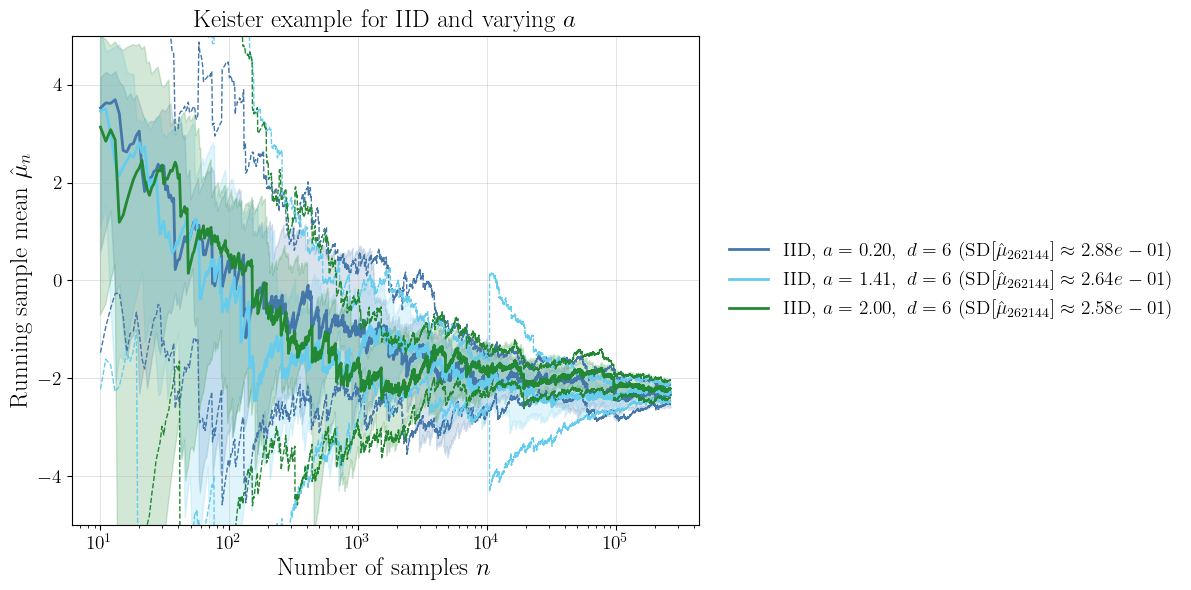

In [18]:
from classlib.plots import plot_middle_half_sample_mean, plot_multiple_middle_half_sample_means
n = 2**16
d = 6
configs = {
    # IID entries
    f"IID a={a:g}, d={d}": {
        "sampler": (lambda n : np.random.random((n, d))),
        "f":       (lambda x : f_keister(x, a)),
        "label":   rf"IID, $a={a:4.2f},\ d={d}$",
    }
    for a in a_list
}

ax, info = plot_multiple_middle_half_sample_means(
    configs,
    n_max=2**18,
    title="Keister example for IID and varying $a$",
    ylim=(-5,5)
)


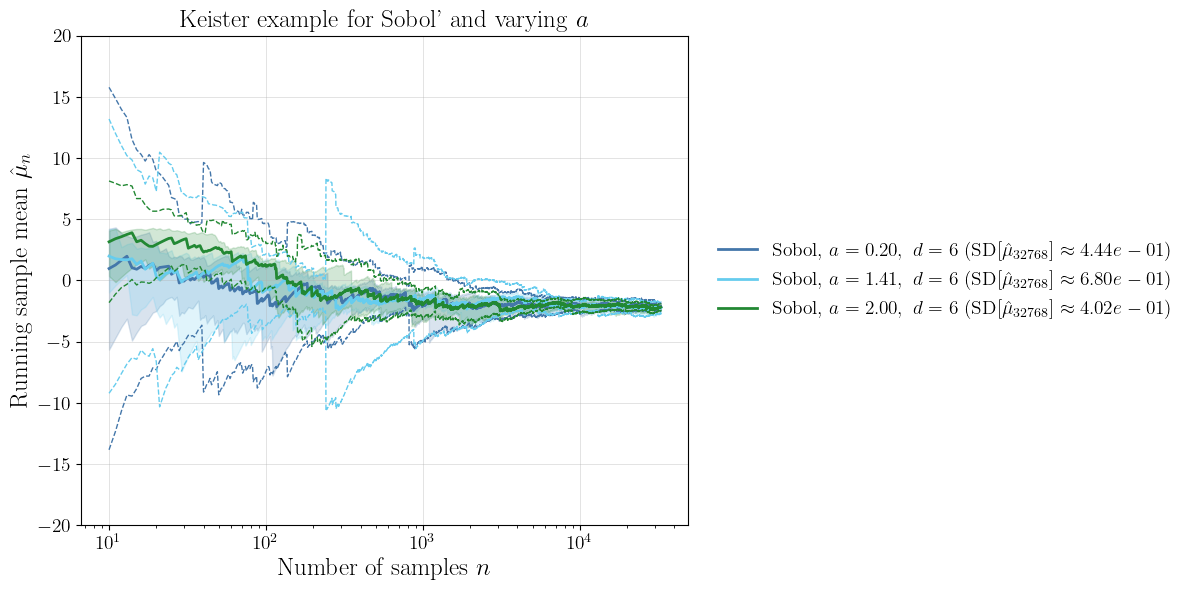

In [19]:
from classlib.plots import plot_middle_half_sample_mean, plot_multiple_middle_half_sample_means
n = 2**16
d = 6
configs = {
    # Sobol entries
    f"Sobol a={a:g}, d={d}": {
        "sampler": (lambda n : qp.Sobol(d).gen_samples(n)),
        "f":       (lambda x : f_keister(x, a)),
        "label":   rf"Sobol, $a={a:4.2f},\ d={d}$",
    }
    for a in a_list
}

ax, info = plot_multiple_middle_half_sample_means(
    configs,
    title="Keister example for Sobol' and varying $a$",
    ylim=(-20,20)
)
